# Learning 7: Loops in Graphs

**Goal**: Create graphs that can repeat steps until a condition is met

## What You'll Learn
- Creating cycles in graphs
- Implementing retry logic
- Building iterative refinement workflows

In [1]:
from dotenv import load_dotenv
load_dotenv()

from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Image, display

print("Setup complete!")

/Users/syedraza/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Setup complete!


## Why Loops?

Many real-world workflows need iteration:
- Retry until success
- Refine output until it meets criteria
- Process items one at a time
- Agent tool-calling loops

```
              ┌──────────────┐
              ↓              │ (not done)
[START] → [Process] ────────┘
              │
              ↓ (done)
            [END]
```

## Example 1: Simple Counter Loop

In [2]:
class CounterState(TypedDict):
    count: int
    target: int
    log: list

def increment(state: CounterState) -> dict:
    """Increment the counter by 1."""
    new_count = state["count"] + 1
    new_log = state["log"] + [f"Count is now {new_count}"]
    return {"count": new_count, "log": new_log}

def should_continue(state: CounterState) -> str:
    """Check if we should continue looping."""
    if state["count"] < state["target"]:
        return "continue"
    return "done"

In [3]:
# Build the graph with a loop
builder = StateGraph(CounterState)

builder.add_node("increment", increment)

builder.add_edge(START, "increment")

# This is the key: conditional edge that can loop back!
builder.add_conditional_edges(
    "increment",
    should_continue,
    {
        "continue": "increment",  # Loop back to increment
        "done": END                # Exit the loop
    }
)

app = builder.compile()

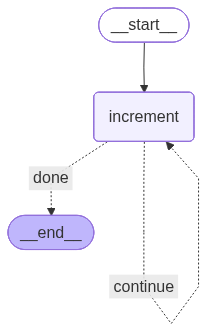

In [4]:
# Visualize - notice the cycle!
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except:
    print(app.get_graph().draw_ascii())

In [ ]:
# Run the loop
result = app.invoke({"count": 0, "target": 5, "log": []})

print("Final count:", result["count"])
print("Log:")
for entry in result["log"]:
    print(f"  - {entry}")

## Example 2: Retry Until Success

In [ ]:
import random

class RetryState(TypedDict):
    attempts: int
    max_attempts: int
    success: bool
    result: str

def attempt_operation(state: RetryState) -> dict:
    """Simulate an operation that sometimes fails."""
    attempts = state["attempts"] + 1
    
    # 30% chance of success on each attempt
    success = random.random() < 0.3
    
    if success:
        result = f"Success on attempt {attempts}!"
    else:
        result = f"Attempt {attempts} failed"
    
    print(result)
    return {"attempts": attempts, "success": success, "result": result}

def should_retry(state: RetryState) -> str:
    """Determine if we should retry."""
    if state["success"]:
        return "success"
    elif state["attempts"] >= state["max_attempts"]:
        return "max_reached"
    else:
        return "retry"

def handle_success(state: RetryState) -> dict:
    return {"result": f"Operation completed successfully after {state['attempts']} attempts"}

def handle_failure(state: RetryState) -> dict:
    return {"result": f"Operation failed after {state['max_attempts']} attempts"}

In [ ]:
builder = StateGraph(RetryState)

builder.add_node("attempt", attempt_operation)
builder.add_node("success", handle_success)
builder.add_node("failure", handle_failure)

builder.add_edge(START, "attempt")

builder.add_conditional_edges(
    "attempt",
    should_retry,
    {
        "retry": "attempt",     # Loop back
        "success": "success",   # Go to success handler
        "max_reached": "failure" # Go to failure handler
    }
)

builder.add_edge("success", END)
builder.add_edge("failure", END)

app = builder.compile()

In [ ]:
# Run multiple times to see different outcomes
result = app.invoke({
    "attempts": 0,
    "max_attempts": 5,
    "success": False,
    "result": ""
})

print("\nFinal result:", result["result"])

## Example 3: Iterative Refinement

In [ ]:
class RefinementState(TypedDict):
    text: str
    quality_score: int
    iterations: int
    max_iterations: int
    history: list

def refine_text(state: RefinementState) -> dict:
    """Simulate text refinement."""
    # In reality, this would use an LLM
    text = state["text"]
    iterations = state["iterations"] + 1
    
    # Simulate improvement
    improvements = [
        text.capitalize(),
        text + " (improved)",
        text.replace("good", "excellent"),
        text + "!"
    ]
    
    new_text = improvements[min(iterations - 1, len(improvements) - 1)]
    new_score = min(100, state["quality_score"] + random.randint(15, 30))
    
    history = state["history"] + [f"Iteration {iterations}: score={new_score}"]
    
    return {
        "text": new_text,
        "quality_score": new_score,
        "iterations": iterations,
        "history": history
    }

def check_quality(state: RefinementState) -> str:
    """Check if quality threshold is met."""
    if state["quality_score"] >= 80:
        return "good_enough"
    elif state["iterations"] >= state["max_iterations"]:
        return "max_iterations"
    else:
        return "needs_improvement"

In [ ]:
builder = StateGraph(RefinementState)

builder.add_node("refine", refine_text)

builder.add_edge(START, "refine")

builder.add_conditional_edges(
    "refine",
    check_quality,
    {
        "needs_improvement": "refine",  # Loop
        "good_enough": END,
        "max_iterations": END
    }
)

app = builder.compile()

In [ ]:
result = app.invoke({
    "text": "this is a good start",
    "quality_score": 20,
    "iterations": 0,
    "max_iterations": 5,
    "history": []
})

print("Final text:", result["text"])
print("Final score:", result["quality_score"])
print("Iterations:", result["iterations"])
print("\nHistory:")
for h in result["history"]:
    print(f"  {h}")

## Streaming Loop Execution

Watch the loop execute step by step.

In [ ]:
# Stream to see each iteration
print("Streaming loop execution:")
print("=" * 40)

for step in app.stream({
    "text": "hello",
    "quality_score": 10,
    "iterations": 0,
    "max_iterations": 5,
    "history": []
}):
    print(step)
    print("-" * 40)

## Important: Preventing Infinite Loops

Always include a safety condition:
- Maximum iterations counter
- Timeout
- Other exit conditions

In [ ]:
# Good pattern: always check iteration count
def safe_loop_check(state) -> str:
    # Always have a maximum!
    if state["iterations"] >= state["max_iterations"]:
        return "stop"  # Safety exit
    
    # Normal condition check
    if state["condition_met"]:
        return "stop"
    
    return "continue"

## Exercise: Build a Guessing Game

Create a graph that:
1. Picks a random number 1-10
2. Makes guesses
3. Loops until correct or max guesses reached
4. Tracks all guesses made

In [ ]:
# Your code here!



## Key Takeaways

1. Loops are created by routing back to a previous node
2. Always include exit conditions to prevent infinite loops
3. Use counters or quality checks to control iterations
4. Streaming shows each iteration as it happens
5. Common patterns: retry, refinement, processing lists

**Next**: Learning 8 - Agent with Tools